# 🚢 타이타닉 데이터 분석 기초: 데이터 무결성 검증 (EDA)

이 주피터 노트북은 **데이터 분석을 처음 시작하는 입문자**를 위한 실습 가이드입니다.
데이터 분석의 첫 단계인 **결측치(Missing Values), 중복값(Duplicates), 이상치(Outliers)**를 직접 코드로 확인하고 시각화합니다.

> **💡 주피터 노트북 팁:**
> - 실행하고 싶은 셀을 클릭한 후 `Shift + Enter`를 누르면 해당 셀이 실행되고 다음 셀로 넘어갑니다.
> - 위쪽 툴바의 `Run` 버튼을 눌러도 실행됩니다.

## 0. 필수 라이브러리 불러오기 및 한글 폰트 설정
- `pandas`: 표 형태의 데이터(DataFrame)를 다루는 가장 핵심적인 라이브러리
- `numpy`: 수치 계산 및 통계 처리를 위한 라이브러리
- `matplotlib` & `seaborn`: 데이터 시각화 차트를 그리기 위한 라이브러리

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Mac: AppleGothic, Windows: Malgun Gothic)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 준비 완료!")

라이브러리 준비 완료!


## 1. 데이터 불러오기 및 기본 구조 파악
`pd.read_csv()`를 사용해 타이타닉 데이터셋을 불러오고, `head()`와 `info()`로 데이터의 형태를 확인합니다.

In [2]:
# CSV 파일 불러오기
df = pd.read_csv("data/Titanic-Dataset.csv")

# 상위 5개 행 미리보기
print(f"전체 데이터 크기: {df.shape[0]}행 × {df.shape[1]}열")
df.head()

전체 데이터 크기: 891행 × 12열


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# 컬럼별 데이터 타입 및 결측치 현황 요약
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## 2. 결측치(Missing Values / NaN) 검증
- **결측치란?** 데이터 수집 과정에서 누락되거나 비어 있는 값입니다.
- 판다스에서는 `df.isnull().sum()`으로 각 컬럼별 결측치 개수를 셀 수 있습니다.

In [4]:
# 결측치 개수 및 비율 계산
missing_count = df.isnull().sum()
missing_ratio = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    '결측치 개수': missing_count,
    '결측 비율(%)': missing_ratio.round(2)
})

# 결측치가 있는 컬럼만 내림차순 정렬
missing_df[missing_df['결측치 개수'] > 0].sort_values(by='결측치 개수', ascending=False)

,결측치 개수,결측 비율(%)
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


findfont: Failed to find font weight bold, now using 400.


findfont: Failed to find font weight bold, now using 400.


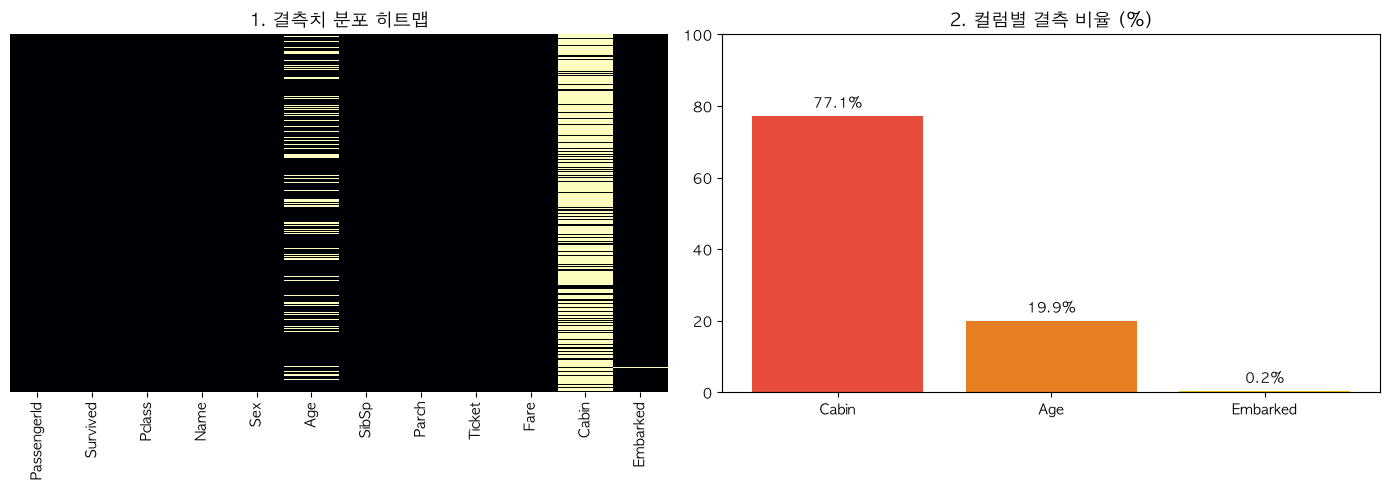

In [5]:
# 결측치 시각화: 히트맵(Heatmap)과 막대 그래프
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) 히트맵 (밝은 선 = 결측치)
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='magma', ax=axes[0])
axes[0].set_title("1. 결측치 분포 히트맵", fontsize=13, fontweight='bold')

# 2) 결측 비율 막대 그래프
missing_only = missing_df[missing_df['결측 비율(%)'] > 0].sort_values(by='결측 비율(%)', ascending=False)
bars = axes[1].bar(missing_only.index, missing_only['결측 비율(%)'], color=['#e74c3c', '#e67e22', '#f1c40f'])
axes[1].set_title("2. 컬럼별 결측 비율 (%)", fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 100)
for bar in bars:
    h = bar.get_height()
    axes[1].annotate(f'{h:.1f}%', xy=(bar.get_x() + bar.get_width()/2, h), xytext=(0, 3),
                     textcoords='offset points', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. 중복값(Duplicate Rows) 검증
- **중복값이란?** 동일한 데이터 행이 2개 이상 들어간 경우입니다.
- 중복 데이터는 모델을 편향되게 만들 수 있으므로 `df.duplicated().sum()`으로 확인합니다.

In [6]:
dup_count = df.duplicated().sum()
print(f"완전히 동일한 중복 행 수: {dup_count}건")

# 고유 식별자인 PassengerId 중복 확인
id_dups = df['PassengerId'].duplicated().sum()
print(f"고유 식별자(PassengerId) 중복: {id_dups}건")

완전히 동일한 중복 행 수: 0건
고유 식별자(PassengerId) 중복: 0건


## 4. 이상치(Outliers) 검증 (IQR 방식 & Boxplot)
- **이상치란?** 대다수 데이터의 범위에서 크게 동떨어진 극단적인 값입니다.
- **IQR (사분위수 범위) 판별 공식:**
  - $Q_1$: 하위 25% 지점 값
  - $Q_3$: 상위 25% (하위 75%) 지점 값
  - $IQR = Q_3 - Q_1$
  - **정상 범위:** $[Q_1 - 1.5 \times IQR,\; Q_3 + 1.5 \times IQR]$
  - 이 범위를 벗어난 값을 이상치로 분류합니다.

In [7]:
def check_iqr(series, col_name):
    clean_series = series.dropna()
    q1 = clean_series.quantile(0.25)
    q3 = clean_series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = clean_series[(clean_series < lower) | (clean_series > upper)]
    print(f"[{col_name}] Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")
    print(f"[{col_name}] 정상 범위: {lower:.2f} ~ {upper:.2f}")
    print(f"[{col_name}] 이상치 개수: {len(outliers)}건 ({len(outliers)/len(clean_series)*100:.2f}%)\n")

check_iqr(df['Age'], '나이(Age)')
check_iqr(df['Fare'], '운임요금(Fare)')

[나이(Age)] Q1: 20.12, Q3: 38.00, IQR: 17.88
[나이(Age)] 정상 범위: -6.69 ~ 64.81
[나이(Age)] 이상치 개수: 11건 (1.54%)

[운임요금(Fare)] Q1: 7.91, Q3: 31.00, IQR: 23.09
[운임요금(Fare)] 정상 범위: -26.72 ~ 65.63
[운임요금(Fare)] 이상치 개수: 116건 (13.02%)



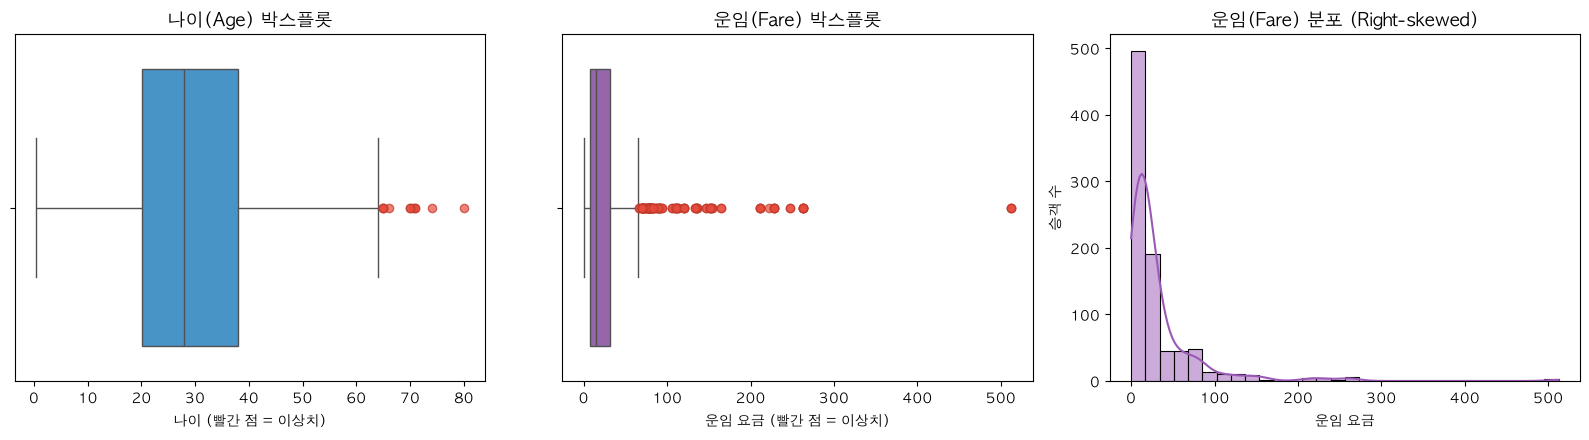

In [8]:
# Boxplot 및 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
flier = dict(marker='o', markerfacecolor='#e74c3c', markeredgecolor='#c0392b', markersize=6, alpha=0.7)

# 1) Age 박스플롯
sns.boxplot(x=df['Age'], ax=axes[0], color='#3498db', flierprops=flier)
axes[0].set_title("나이(Age) 박스플롯", fontsize=13, fontweight='bold')
axes[0].set_xlabel("나이 (빨간 점 = 이상치)")

# 2) Fare 박스플롯
sns.boxplot(x=df['Fare'], ax=axes[1], color='#9b59b6', flierprops=flier)
axes[1].set_title("운임(Fare) 박스플롯", fontsize=13, fontweight='bold')
axes[1].set_xlabel("운임 요금 (빨간 점 = 이상치)")

# 3) Fare 분포 (히스토그램 & KDE)
sns.histplot(df['Fare'].dropna(), kde=True, ax=axes[2], color='#9b59b6', bins=30)
axes[2].set_title("운임(Fare) 분포 (Right-skewed)", fontsize=13, fontweight='bold')
axes[2].set_xlabel("운임 요금")
axes[2].set_ylabel("승객 수")

plt.tight_layout()
plt.show()

## 5. 핵심 요약 및 다음 단계

1. **결측치:**
   - `Cabin`은 결측 비율(77.1%)이 너무 높아 열을 제거하거나 객실 구역 알파벳만 추출 고려
   - `Age`는 결측 비율(19.9%)이 유의미하므로 중앙값 또는 그룹별 평균으로 대체(Imputation)
   - `Embarked`는 2건만 누락되었으므로 최빈값('S')으로 대체
2. **중복값:**
   - 중복 행 0건으로 별도 제거 작업 불필요
3. **이상치:**
   - `Fare`의 초고액 요금($500+)은 오기입이 아니라 1등석 승객의 실제 값이므로 삭제 대신 로그 변환(`np.log1p`) 활용 가능

--- 
수고하셨습니다! 이제 이 노트북의 셀들을 자유롭게 수정하며 다양한 컬럼을 탐색해 보세요.